# Explore vertical image cropping

Load a tall screenshot with Pillow, preview it, divide it into shorter full-width images, and save the results.

In [1]:
from pathlib import Path

from IPython.display import display
from PIL import Image

## Locate and load the source image

The path logic supports launching JupyterLab from either the repository root or the `notebooks` directory. Pillow opens the file lazily, so `image.load()` reads its pixel data before we inspect it.

In [32]:
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

image_path = repo_root / "images" / "2026_09_10.jpg"
if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

with Image.open(image_path) as source:
    image = source.copy()

print(f"Path: {image_path}")
print(f"Size: {image.width} x {image.height} pixels")
print(f"Mode: {image.mode}")

Path: C:\Users\Johnson\MDS\TransactionsVisualizer\images\2026_09_10.jpg
Size: 540 x 5352 pixels
Mode: RGB


## Preview a smaller copy

`thumbnail()` changes only the preview copy; it does not alter the full-resolution image used for cropping.

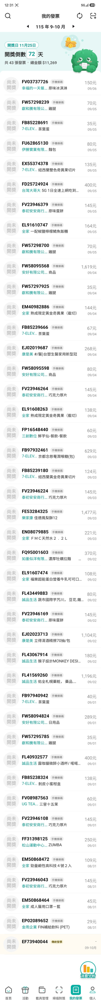

In [33]:
preview = image.copy()
preview.thumbnail((500, 1000))
display(preview)

## Crop into vertical chunks

Pillow crop coordinates are `(left, top, right, bottom)`. Each crop below retains the full width. Change `chunk_height` to control the maximum output height; the final chunk may be shorter.

In [34]:
# chunk_height = 700
# output_dir = repo_root / "images" / "crops" / image_path.stem
# output_dir.mkdir(parents=True, exist_ok=True)

# output_paths = []
# for chunk_number, top in enumerate(range(0, image.height, chunk_height), start=1):
#     bottom = min(top + chunk_height, image.height)
#     crop_box = (0, top, image.width, bottom)
#     chunk = image.crop(crop_box)

#     output_path = output_dir / f"{image_path.stem}_chunk_{chunk_number:03d}.jpg"
#     chunk.save(output_path, quality=95, subsampling=0)
#     output_paths.append(output_path)

# print(f"Saved {len(output_paths)} chunks to {output_dir}")
# for path in output_paths:
#     print(path.name)

## Verify and display the outputs

The height check confirms that the chunks cover the original image exactly, with no missing or duplicated rows.

In [35]:
# saved_chunks = []
# for path in output_paths:
#     with Image.open(path) as saved:
#         saved_chunks.append(saved.copy())

# assert all(chunk.width == image.width for chunk in saved_chunks)
# assert sum(chunk.height for chunk in saved_chunks) == image.height

# for path, chunk in zip(output_paths, saved_chunks):
#     print(f"{path.name}: {chunk.width} x {chunk.height}")
#     display(chunk)

## Crop alternating bands with skipped rows

This strategy begins after a configurable vertical offset. It saves a 107-pixel band, skips 2 pixels, saves a 108-pixel band, skips 2 pixels, and repeats to the bottom. If the image ends partway through a band, the remaining partial band is saved. The initial offset and skipped rows are intentionally absent from the outputs.

In [38]:
initial_offset = 400  # Change this to the number of rows to ignore at the top.
crop_heights = (108, 107)
gap_height = 2

if not 0 <= initial_offset < image.height:
    raise ValueError(f"initial_offset must be between 0 and {image.height - 1}")

pattern_output_dir = (
    repo_root / "images" / "crops" / f"{image_path.stem}_alternating_bands"
)
pattern_output_dir.mkdir(parents=True, exist_ok=True)

pattern_output_paths = []
crop_records = []
top = initial_offset
band_index = 0

while top < image.height:
    requested_height = crop_heights[band_index % len(crop_heights)]
    bottom = min(top + requested_height, image.height)
    band = image.crop((0, top, image.width, bottom))

    output_path = pattern_output_dir / (
        f"{image_path.stem}_band_{band_index + 1:03d}_y{top}-{bottom}.jpg"
    )
    band.save(output_path, quality=95, subsampling=0)
    pattern_output_paths.append(output_path)
    crop_records.append(
        {
            "band": band_index + 1,
            "top": top,
            "bottom": bottom,
            "height": bottom - top,
            "requested_height": requested_height,
        }
    )

    top = bottom + gap_height
    band_index += 1

print(f"Saved {len(pattern_output_paths)} bands to {pattern_output_dir}")

Saved 46 bands to C:\Users\Johnson\MDS\TransactionsVisualizer\images\crops\2026_09_10_alternating_bands


### Inspect the crop coordinates and results

The filenames include each band's original vertical coordinates. The checks confirm that full bands alternate between 107 and 108 pixels and that consecutive bands are separated by 2 pixels.

Band 001: rows 400:508 (108 px) -> 2026_09_10_band_001_y400-508.jpg
Band 002: rows 510:617 (107 px) -> 2026_09_10_band_002_y510-617.jpg
Band 003: rows 619:727 (108 px) -> 2026_09_10_band_003_y619-727.jpg
Band 004: rows 729:836 (107 px) -> 2026_09_10_band_004_y729-836.jpg
Band 005: rows 838:946 (108 px) -> 2026_09_10_band_005_y838-946.jpg
Band 006: rows 948:1055 (107 px) -> 2026_09_10_band_006_y948-1055.jpg
Band 007: rows 1057:1165 (108 px) -> 2026_09_10_band_007_y1057-1165.jpg
Band 008: rows 1167:1274 (107 px) -> 2026_09_10_band_008_y1167-1274.jpg
Band 009: rows 1276:1384 (108 px) -> 2026_09_10_band_009_y1276-1384.jpg
Band 010: rows 1386:1493 (107 px) -> 2026_09_10_band_010_y1386-1493.jpg
Band 011: rows 1495:1603 (108 px) -> 2026_09_10_band_011_y1495-1603.jpg
Band 012: rows 1605:1712 (107 px) -> 2026_09_10_band_012_y1605-1712.jpg
Band 013: rows 1714:1822 (108 px) -> 2026_09_10_band_013_y1714-1822.jpg
Band 014: rows 1824:1931 (107 px) -> 2026_09_10_band_014_y1824-1931.jpg
Band 015: rows

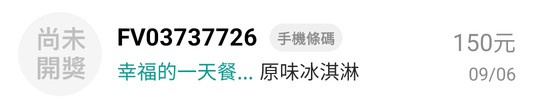

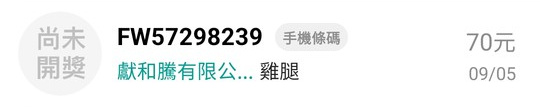

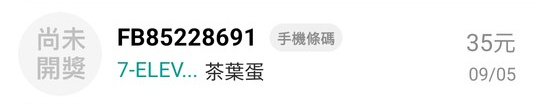

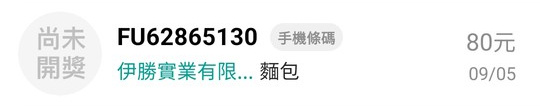

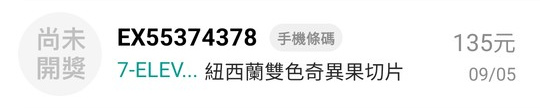

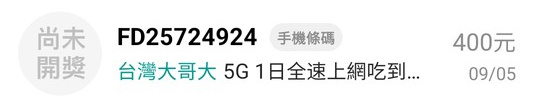

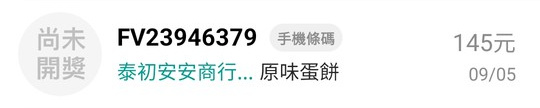

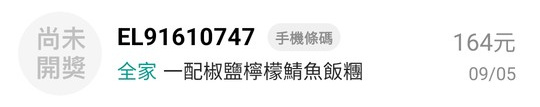

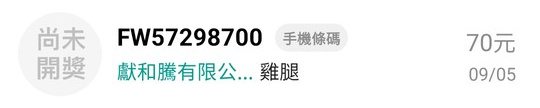

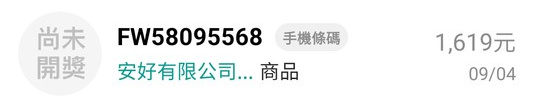

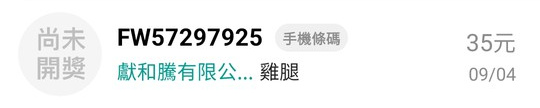

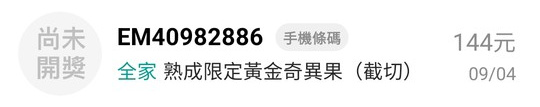

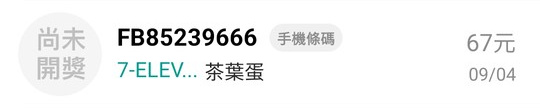

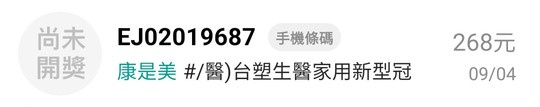

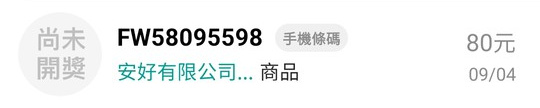

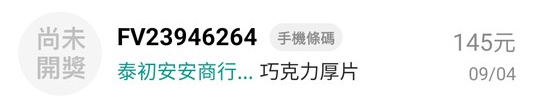

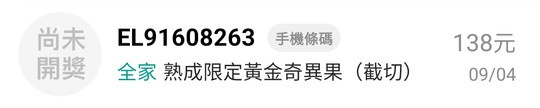

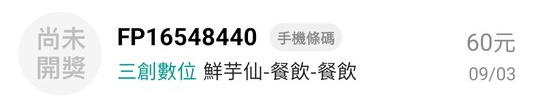

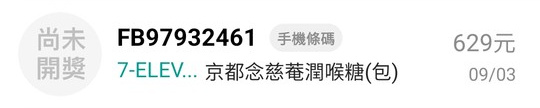

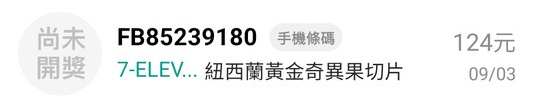

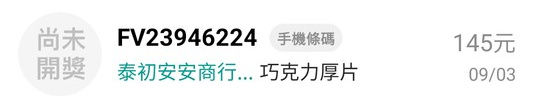

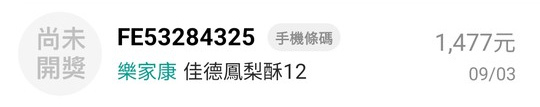

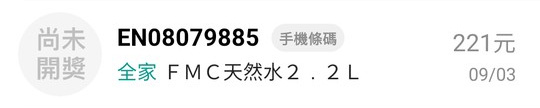

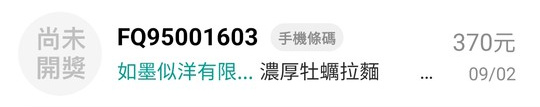

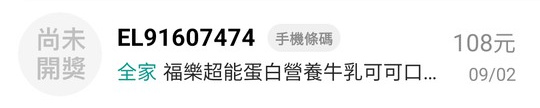

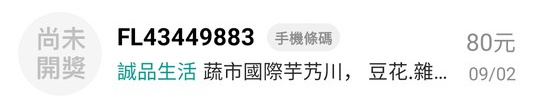

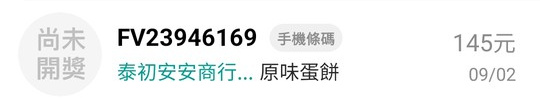

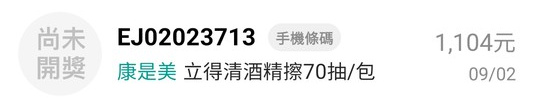

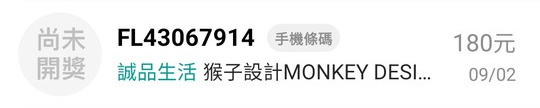

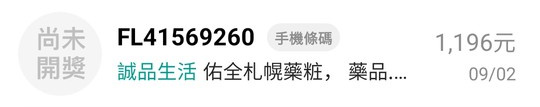

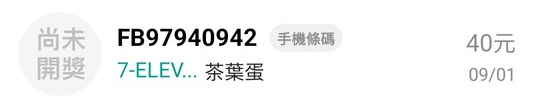

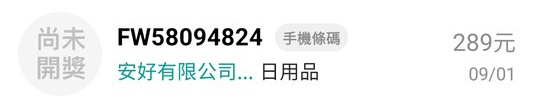

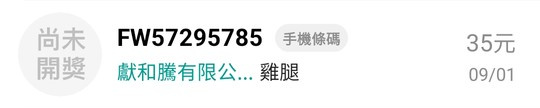

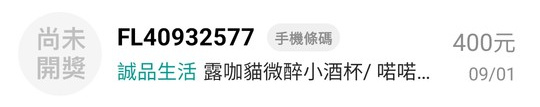

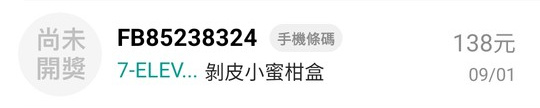

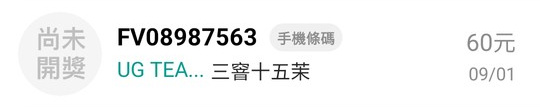

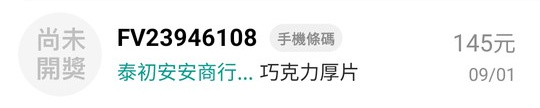

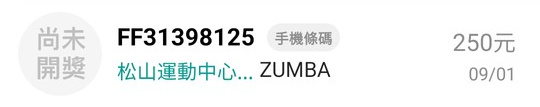

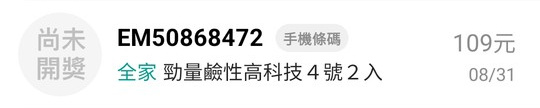

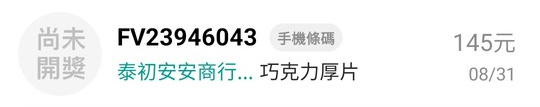

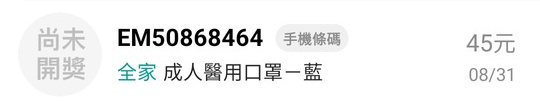

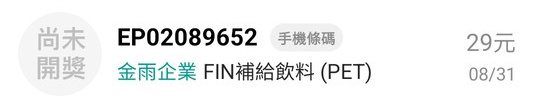

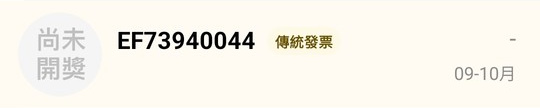

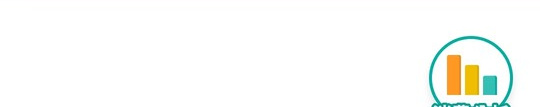

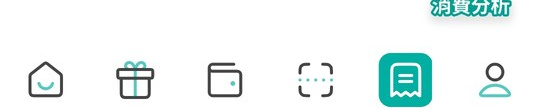

In [39]:
for index, record in enumerate(crop_records):
    is_final_partial_band = (
        index == len(crop_records) - 1
        and record["height"] < record["requested_height"]
    )
    if not is_final_partial_band:
        assert record["height"] == crop_heights[index % len(crop_heights)]
    if index > 0:
        assert record["top"] - crop_records[index - 1]["bottom"] == gap_height

    print(
        f"Band {record['band']:03d}: rows {record['top']}:{record['bottom']} "
        f"({record['height']} px) -> {pattern_output_paths[index].name}"
    )

for path in pattern_output_paths:
    with Image.open(path) as band:
        display(band.copy())